<img src="../../images/bwHPC_Logo_cmyk.svg" width="200" /> <img src="../../images/HochschuleEsslingen_Logo_RGB_DE.png" width="200" /> <img src="../../images/Konstanz_Logo.svg" width="200" /> <img src="../../images/KIT_Logo.png" width="200" />

# Image Processing with Convolutional Neural Networks

> **Please reserve a GPU before you start.** This notebook trains a network on
> 12,000 images, and on a CPU alone that takes a very long time. If your current
> session does not have a GPU, stop it and start a new one with a GPU requested in
> the resource selection. One section of this notebook is specifically about
> *showing you* what that difference looks like.

In the previous two notebooks we saw that a neural network can find structure in
**tabular data** — rows and columns of numbers, where every column already had a
clear meaning.

This notebook is about a different kind of data. We give the network **photographs**
and ask it to tell us what is in them. There are no columns here, no
`median_income`, nothing that was measured and written down by a human. There is
only a grid of coloured dots. Everything the network uses to make its decision it
will have to find in that grid by itself.

The task: **given a photo, is this a cat or a dog?**

---

## Contents

1. [The data](#data)
2. [A first look at the images](#look)
3. [What an image actually is](#pixels)
4. [More training data for free: augmentation](#augment)
5. [How a CNN looks at an image](#grid)
6. [The architecture of a CNN](#cnn)
7. [Building the model](#build)
8. [CPU vs GPU](#hardware)
9. [Training the model](#train)
10. [Evaluation](#evaluation)

<a id="data"></a>
## 1. The data

The images are delivered as a single **zip archive**, `Dogs_And_Cats.zip`. A zip
file is a compressed container: 12,000 separate files bundled into one and squeezed
down in size, which makes them far easier to move around than 12,000 loose files.
Before we can use them, we have to unpack the archive.

Unzipping produces a folder `Dogs_And_Cats/` with this structure:

```
Dogs_And_Cats/
├── train/
│   ├── Cat/     4800 images
│   └── Dog/     4800 images
└── test/
    ├── Cat/     1200 images
    └── Dog/     1200 images
```

Note that the split into training and test data has already been made for us, and
that the **folder names are the labels**. There is no column saying "cat" anywhere —
an image is a cat because it sits in the `Cat` folder. That is a very common
convention for image datasets, and the loading function we use in a moment relies
on exactly it.

*Data source: [https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset/data](https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset/data)*

> This project uses data licensed under Apache License 2.0. Modifications were made to the original dataset.

In [3]:
!unzip -q -o Dogs_And_Cats.zip -d Dogs_And_Cats
!ls Dogs_And_Cats/train Dogs_And_Cats/test

Dogs_And_Cats/test:
Cat  Dog

Dogs_And_Cats/train:
Cat  Dog


Now TensorFlow. The second line lists the GPUs it can see — if that list comes
back empty, everything in this notebook still works, but the training sections will
be slow.

In [24]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("GPUs found:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Loading the images

`image_dataset_from_directory` walks through a folder, reads every image it finds,
and hands back something the network can train on. The arguments:

- **the directory** — it looks at the sub-folders (`Cat`, `Dog`), sorts their names
  alphabetically, and uses them as the class labels. `Cat` becomes 0, `Dog` becomes 1.
- **`image_size`** — every image is resized to this. A network has a fixed number of
  input values, so all images must have identical dimensions. Ours are already
  128 × 128, so nothing actually changes here, but the argument is still required.
- **`batch_size`** — how many images are handed to the network at once, the same
  idea as in the previous notebooks.
- **`label_mode="binary"`** — we have exactly two classes, so each label is a single
  0 or 1 rather than a list of class probabilities.
- **`shuffle`** — the training data is shuffled so that the network does not see
  4800 cats followed by 4800 dogs. The test data is left in its original order,
  which makes the evaluation at the end reproducible.

In [4]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "Dogs_And_Cats/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=123,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "Dogs_And_Cats/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False,
)

class_names = train_ds.class_names
print("class names:", class_names)

Found 9600 files belonging to 2 classes.
Found 2400 files belonging to 2 classes.
class names: ['Cat', 'Dog']


<a id="look"></a>
## 2. A first look at the images

Before building anything, let us first examine the data we are working with. To get an initial impression of the dataset, we select one cat image and one dog image from the training set and display them in the following two cells.

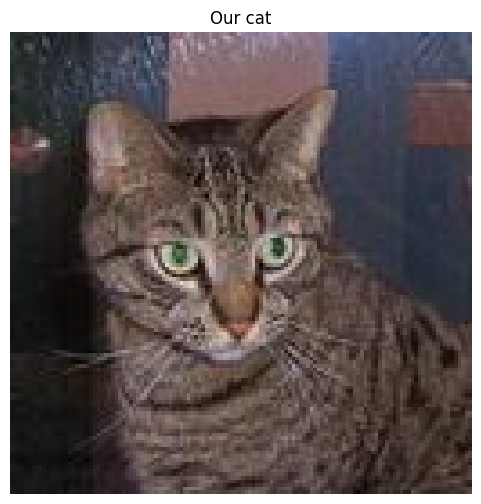

In [4]:
first_cat = tf.keras.utils.img_to_array(
    tf.keras.utils.load_img("Dogs_And_Cats/train/Cat/0.jpg")
)

plt.figure(figsize=(6, 6))
plt.imshow(first_cat.astype("uint8"))
plt.title("Our cat")
plt.axis("off")
plt.show()

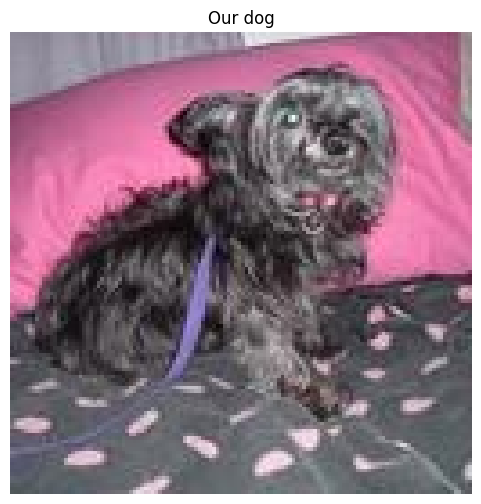

In [5]:
first_dog = tf.keras.utils.img_to_array(
    tf.keras.utils.load_img("Dogs_And_Cats/train/Dog/0.jpg")
)

plt.figure(figsize=(6, 6))
plt.imshow(first_dog.astype("uint8"))
plt.title("Our dog")
plt.axis("off")
plt.show()

One cat tells us very little. The training folder holds 4800 of them, and they
are all over the place: sitting, lying down, looking at the camera, looking away,
close up, far away, on a sofa, on grass, light fur, dark fur.

That variety is the whole difficulty of the task. The network cannot memorise what
"a cat" looks like from one example — it has to find something that all of these
have in common and that none of the dogs have.

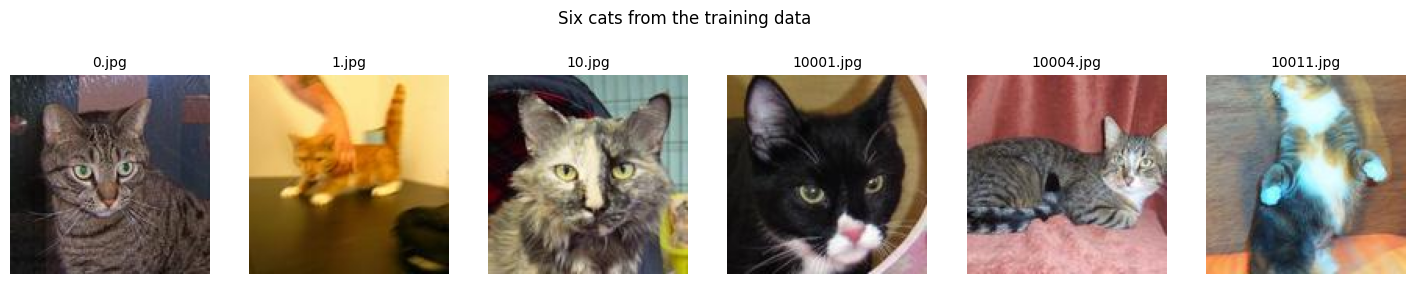

In [6]:
def show_row(folder, files, title):
    fig, axes = plt.subplots(1, len(files), figsize=(3 * len(files), 3.4))
    for ax, name in zip(axes, files):
        image = tf.keras.utils.load_img(os.path.join(folder, name))
        ax.imshow(image)
        ax.set_title(name, fontsize=10)
        ax.axis("off")
    fig.suptitle(title)
    plt.show()


cat_folder = "Dogs_And_Cats/train/Cat"
cat_files = sorted(os.listdir(cat_folder))[:6]
show_row(cat_folder, cat_files, "Six cats from the training data")

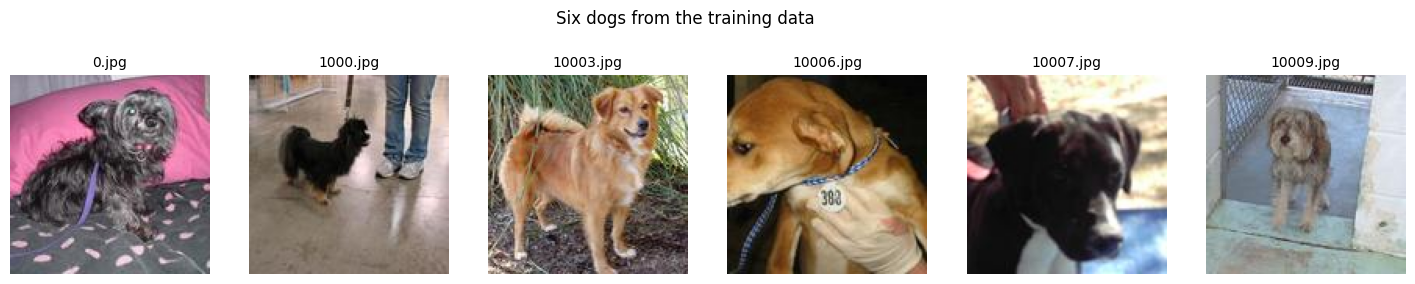

In [7]:
dog_folder = "Dogs_And_Cats/train/Dog"
dog_files = sorted(os.listdir(dog_folder))[:6]
show_row(dog_folder, dog_files, "Six dogs from the training data")

<a id="pixels"></a>
## 3. What an image actually is

To a computer this photograph is not a cat. It is a grid of **pixels**, and every
pixel is nothing but three numbers: how much **red**, how much **green** and how
much **blue** it contains, each on a scale from 0 to 255.

The figure below takes our cat, cuts out a tiny square, and blows it up until the
individual pixels become visible. On the right, one of those pixels is picked apart
into its three values.

![From image to pixels to numbers](../../images/cnn_pixels.png)

That structure shows up directly in the shape of the array. The last number is the
**channel dimension**, and it is 3 because every pixel carries those three values —
red, green and blue.

In [8]:
print("shape of our cat:", first_cat.shape)
print()
print("  height  :", first_cat.shape[0], "pixels")
print("  width   :", first_cat.shape[1], "pixels")
print("  channels:", first_cat.shape[2], "-> red, green, blue")
print()
print("total numbers in this one image:", first_cat.size)

shape of our cat: (128, 128, 3)

  height  : 128 pixels
  width   : 128 pixels
  channels: 3 -> red, green, blue

total numbers in this one image: 49152


<a id="augment"></a>
## 4. More training data for free: augmentation

4800 cats sounds like a lot, but for image recognition it is not much. And there is
a cheap trick to get more: take the images we already have and **modify them
slightly**. A photo of a cat flipped left-to-right is still a photo of a cat, but as
far as the network is concerned it is a new example it has never seen.

This is called **data augmentation**, and it does more than pad the numbers. It
forces the network to learn what a cat *is*, rather than memorising the exact
arrangement of pixels in one particular photograph.

We use three transformations:

- a **horizontal flip** — mirror the image left to right
- a **rotation** — turn it slightly
- a **zoom** — move a little closer or further away

Each one is applied by a Keras layer, and each is **random**: the flip happens to
roughly half the images, the rotation and zoom pick a small amount each time. So
running the cells below twice will not give you the same picture twice.

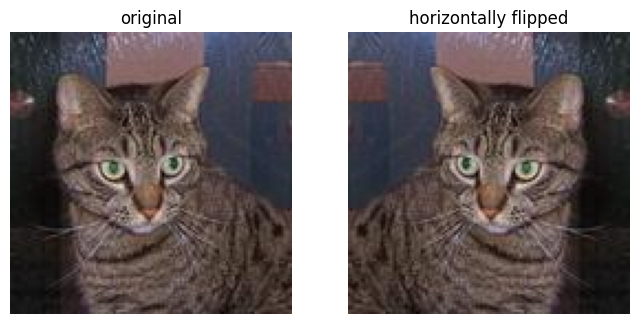

In [9]:
def compare(changed, title):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4.4))
    for ax, image, name in zip(axes, [first_cat, changed], ["original", title]):
        ax.imshow(np.clip(image, 0, 255).astype("uint8"))
        ax.set_title(name)
        ax.axis("off")
    plt.show()


flip_layer = layers.RandomFlip("horizontal")
flipped = flip_layer(tf.expand_dims(first_cat, 0), training=True)[0].numpy()
compare(flipped, "horizontally flipped")

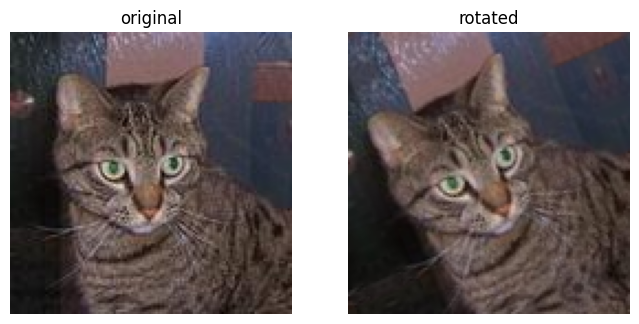

In [14]:
rotation_layer = layers.RandomRotation(0.1)
rotated = rotation_layer(tf.expand_dims(first_cat, 0), training=True)[0].numpy()
compare(rotated, "rotated")

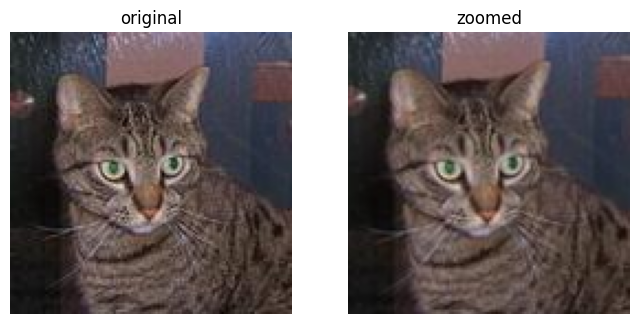

In [19]:
zoom_layer = layers.RandomZoom(0.1)
zoomed = zoom_layer(tf.expand_dims(first_cat, 0), training=True)[0].numpy()
compare(zoomed, "zoomed")

Now the same three steps are applied to the **whole training set**. Because the
transformations are random and are applied every time an image is read, the network
sees a slightly different version of each cat in every epoch.

In [5]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

train_ds_augmented = train_ds.map(
    lambda images, labels: (data_augmentation(images, training=True), labels),
    num_parallel_calls=tf.data.AUTOTUNE,
).prefetch(tf.data.AUTOTUNE)

print("augmentation will be applied to every batch of the training data")

augmentation will be applied to every batch of the training data


<a id="grid"></a>
## 5. How a CNN looks at an image

Here is the difference to everything we did before.

With tabular data the **features were handed to us**. A column was called
`median_income` and it contained the median income; the network only had to work out
how much that mattered. With an image there are no such columns. There is no
`has_pointy_ears` value anywhere in the file — only 49,152 numbers with no labels
attached.

So the network has to **discover the features itself**: edges, then textures, then
shapes like an ear, a snout, a whisker. And the way it does that is by **not**
looking at the whole picture at once. Instead it looks at one small square at a
time, and slides that square across the image — left to right, top to bottom —
asking the same question at every position: *is the thing I am looking for here?*

The figure below splits our cat into a 3 × 3 grid to make the idea visible. A real
network uses a much smaller window than this, and slides it one pixel at a time, but
the principle is exactly the same.

![The image divided into a 3x3 grid](../../images/cnn_image_grid.png)

And these are the nine parts, one at a time, in the order the window travels:
left to right, then down to the next row.

Look at them individually and notice how little each one says on its own. Part
`(0, 0)` is mostly background; part `(1, 1)` is mostly an eye. No single square
is enough to decide "cat" — but together, and combined layer by layer, they are.

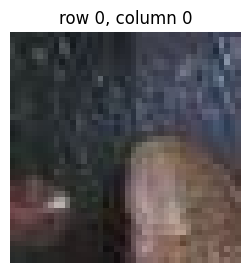

In [11]:
edges = [0, 128 // 3, 2 * 128 // 3, 128]


def show_part(row, col):
    patch = first_cat[edges[row]:edges[row + 1], edges[col]:edges[col + 1]]
    plt.figure(figsize=(3, 3))
    plt.imshow(patch.astype("uint8"))
    plt.title(f"row {row}, column {col}")
    plt.axis("off")
    plt.show()


show_part(0, 0)

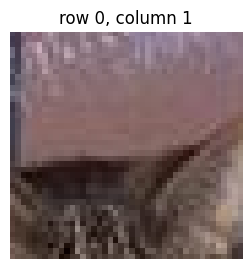

In [12]:
show_part(0, 1)

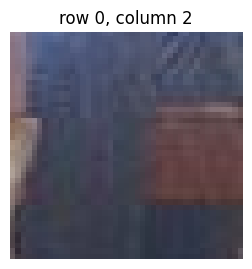

In [13]:
show_part(0, 2)

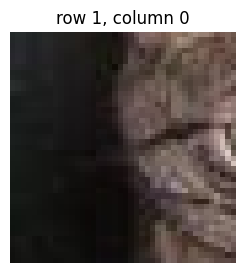

In [14]:
show_part(1, 0)

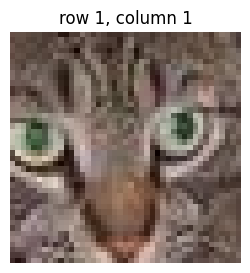

In [15]:
show_part(1, 1)

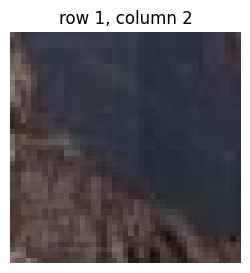

In [16]:
show_part(1, 2)

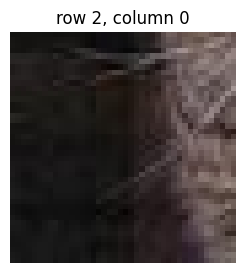

In [17]:
show_part(2, 0)

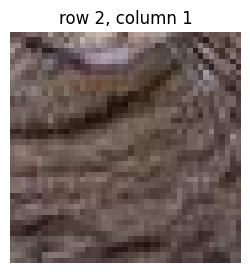

In [18]:
show_part(2, 1)

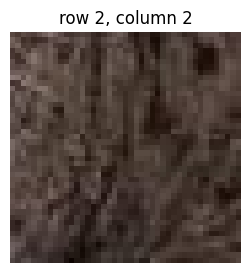

In [19]:
show_part(2, 2)

<a id="cnn"></a>
## 6. The architecture of a CNN

Now we can put the whole thing together. A **convolutional neural network** (CNN)
is what you get when you put a few image-specific layers *in front of* the ordinary
neural network we already know.

![The architecture of a CNN](../../images/cnn_pipeline.svg)

**Convolution** is the sliding-window step from the previous section. A small
window — typically 3 × 3 pixels — is moved across the whole image, and at every
position it computes a single number saying how strongly its particular pattern is
present there. Those numbers, laid back out in the shape of the image, form a
**feature map**: a picture of where that one pattern occurs. A layer does this with
*many* windows at once, so it produces many feature maps — one for "vertical edge
here", one for "this texture here", and so on. The windows are not designed by us;
their contents are weights, learned during training exactly like everything else.

**Max pooling** shrinks each feature map. It slides a small window over the map and
keeps only the largest value in it, throwing the rest away. That sounds crude, and
it is deliberate: what matters is *that* a pattern was found somewhere in that
region, not the exact pixel it sat on. Pooling makes the network's answer stable
when the cat moves slightly, and it cuts the amount of data to process at every
step, which is why the maps get visibly smaller as you go right in the figure.

Convolution and pooling are then repeated several times. Each round works on the
output of the previous one, so the patterns get progressively more complex: the
first layers find edges, the ones after that find combinations of edges, and the
later ones find things we would recognise as ears or eyes.

**Flattening** is the bridge to the familiar part. After the last pooling step we
still have a stack of small two-dimensional maps, but an ordinary `Dense` layer
wants a flat list of numbers. Flattening simply lays every value of every map out
in one long row — no computation, only a change of shape.

From there on it is **exactly the network from the previous two notebooks**: dense
layers, then one output neuron with a sigmoid, giving one probability. High means
dog, low means cat.

<a id="build"></a>
## 7. Building the model

### Rescaling

In the previous notebooks we standardised each column, because a `GRE Score` in the
300s and a `Research` flag of 0 or 1 are on wildly different scales and the network
would have taken the larger numbers more seriously purely because they were larger.

Images do not have that problem: **every** value is already on the same scale, 0 to
255. But those numbers are still large, and large inputs make training unstable. So
all we need is to divide everything by 255, which puts every pixel between 0 and 1.
One `Rescaling` layer does it, and because it sits inside the model, we never have
to remember to apply it by hand to new images.

Note that there are **no augmentation layers** in this model. We already applied
them to the training data in [section 4](#augment).

### The convolution layers

`Conv2D(32, 3, activation="relu")` takes three things:

- **32** — how many different windows this layer learns, and therefore how many
  feature maps it produces
- **3** — the size of the window, 3 × 3 pixels
- **`relu`** — the same activation function as in the previous notebooks

`MaxPooling2D()` halves the height and width, as described above.

We stack four of these convolution/pooling pairs, with the number of filters growing
as the maps get smaller: few, simple patterns at high resolution to begin with; many,
complex patterns at low resolution by the end.

Then `Flatten`, a `Dense` layer, and the single sigmoid output.

`make_model().summary()` is worth reading carefully. Follow the `Output Shape`
column down the table and watch 128 × 128 shrink step by step — and pay particular
attention to the jump at `Flatten`, where a stack of small maps turns into one very
long vector. That number is what the dense layer has to connect to, and it is where
most of the model's parameters come from.

In [6]:
def make_model():
    return tf.keras.Sequential([
        layers.Input(shape=(128, 128, 3)),
        layers.Rescaling(1 / 255.0),

        layers.Conv2D(32, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])


make_model().summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 830,913 (3.17 MB)

 Trainable params: 830,913 (3.17 MB)

 Non-trainable params: 0 (0.00 B)

<a id="hardware"></a>
## 8. CPU vs GPU

A CNN does an enormous number of small, identical multiplications — the same window
applied at every position of every feature map, for every image in the batch. That
is precisely the kind of work a GPU is built for, and it is why the hardware makes
such a difference here. The tabular networks in the previous notebooks were far too
small for this to matter; this one is not.

### First on the CPU

Run the cell below. Once **Epoch 1** starts, TensorFlow prints an estimated time remaining for that epoch. **That first number is what we care about.**

You then have two options:

- wait for the two epochs to finish, or
- **interrupt the cell** with the stop button to its left

Either is fine. We only need the estimated per-epoch time to compare against.

In [7]:
with tf.device("/CPU:0"):
    cpu_model = make_model()
    cpu_model.compile(optimizer="adam",
                      loss="binary_crossentropy",
                      metrics=["accuracy"])
    cpu_model.fit(train_ds_augmented, epochs=2, verbose=1)

Epoch 1/2
300/300 ━━━━━━━━━━━━━━━━━━━━ 323s 1s/step - accuracy: 0.5300 - loss: 0.6910
Epoch 2/2
300/300 ━━━━━━━━━━━━━━━━━━━━ 306s 1s/step - accuracy: 0.6033 - loss: 0.6625


### Now on the GPU

Exactly the same model, exactly the same data, two epochs again. Watch the estimated time
reported for **Epoch 1** and compare it with the number you just saw.

In [22]:
with tf.device("/GPU:0"):
    gpu_model = make_model()
    gpu_model.compile(optimizer="adam",
                      loss="binary_crossentropy",
                      metrics=["accuracy"])
    gpu_model.fit(train_ds_augmented, epochs=2, verbose=1)

Epoch 1/2
300/300 ━━━━━━━━━━━━━━━━━━━━ 35s 95ms/step - accuracy: 0.5309 - loss: 0.6873
Epoch 2/2
300/300 ━━━━━━━━━━━━━━━━━━━━ 29s 96ms/step - accuracy: 0.6424 - loss: 0.6409


<a id="train"></a>
## 9. Training the model

Two epochs is nowhere near enough to learn anything useful — those two runs existed
only to be timed, and both models are now thrown away.

Here we start again with a fresh model and train it properly, for **35 epochs**, on
the GPU. This is the point where reserving one pays off.

In [28]:
with tf.device("/GPU:0"):
    model = make_model()
    model.compile(optimizer="adam",
                  loss="binary_crossentropy",
                  metrics=["accuracy"])

    history = model.fit(train_ds_augmented, epochs=35, verbose=1)

Epoch 1/35
300/300 ━━━━━━━━━━━━━━━━━━━━ 32s 95ms/step - accuracy: 0.5275 - loss: 0.6896
Epoch 2/35
300/300 ━━━━━━━━━━━━━━━━━━━━ 30s 99ms/step - accuracy: 0.6310 - loss: 0.6441
Epoch 3/35
300/300 ━━━━━━━━━━━━━━━━━━━━ 30s 98ms/step - accuracy: 0.6835 - loss: 0.5971
Epoch 4/35
300/300 ━━━━━━━━━━━━━━━━━━━━ 29s 95ms/step - accuracy: 0.7095 - loss: 0.5652
Epoch 5/35
300/300 ━━━━━━━━━━━━━━━━━━━━ 29s 96ms/step - accuracy: 0.7382 - loss: 0.5250
Epoch 6/35
300/300 ━━━━━━━━━━━━━━━━━━━━ 29s 96ms/step - accuracy: 0.7521 - loss: 0.5041
Epoch 7/35
300/300 ━━━━━━━━━━━━━━━━━━━━ 30s 100ms/step - accuracy: 0.7757 - loss: 0.4781
Epoch 8/35
300/300 ━━━━━━━━━━━━━━━━━━━━ 29s 95ms/step - accuracy: 0.7854 - loss: 0.4577
Epoch 9/35
300/300 ━━━━━━━━━━━━━━━━━━━━ 29s 95ms/step - accuracy: 0.7968 - loss: 0.4353
Epoch 10/35
300/300 ━━━━━━━━━━━━━━━━━━━━ 29s 96ms/step - accuracy: 0.8066 - loss: 0.4204
Epoch 11/35
300/300 ━━━━━━━━━━━━━━━━━━━━ 29s 97ms/step - accuracy: 0.8221 - loss: 0.3955
Epoch 12/35
300/300 ━━━━━━━━━

The loss is the number training actually minimises, so its curve is the honest
picture of whether the model kept learning.

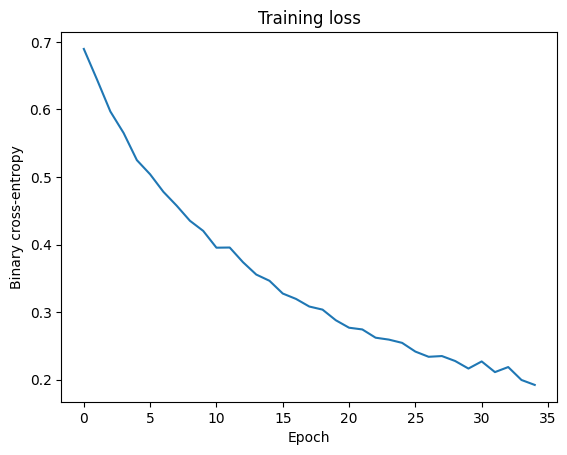

In [29]:
plt.plot(history.history["loss"])
plt.title("Training loss")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.show()

<a id="evaluation"></a>
## 10. Evaluation

The 2400 images in `test/` were never shown to the network during training. Let us
start with three of them, one at a time, and see what the model says.

Each prediction is a probability, exactly as in the classification notebook: close
to 0 means `Cat`, close to 1 means `Dog`, and 0.5 is the threshold between them.

Because we loaded the test data unshuffled, and `Cat` comes before `Dog`
alphabetically, these first three images all happen to be cats. That is expected —
the confusion matrix at the end covers both classes.

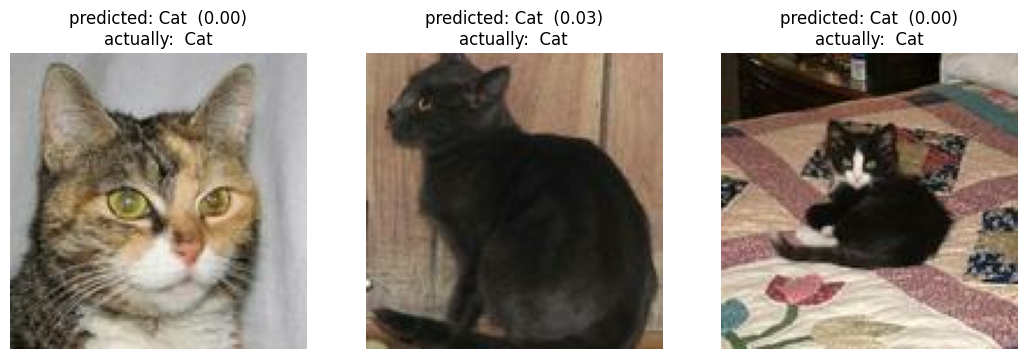

In [33]:
test_images, test_labels = next(iter(test_ds))
probabilities = model.predict(test_images[:3], verbose=0).ravel()

fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
for ax, image, label, p in zip(axes, test_images[:3], test_labels[:3], probabilities):
    ax.imshow(image.numpy().astype("uint8"))
    predicted = class_names[int(p >= 0.5)]
    actual = class_names[int(label.numpy()[0])]
    ax.set_title(f"predicted: {predicted}  ({p:.2f})\nactually:  {actual}")
    ax.axis("off")
plt.show()

Three images prove nothing. Now the whole test set.

In [34]:
from sklearn.metrics import accuracy_score

y_probability = model.predict(test_ds, verbose=0).ravel()
y_predict = (y_probability >= 0.5).astype(int)
y_true = np.concatenate([labels.numpy().ravel() for _, labels in test_ds]).astype(int)

accuracy = accuracy_score(y_true, y_predict)

print(f"Test images: {len(y_true)}")
print(f"Accuracy:    {accuracy:.1%}")
print(f"Baseline (always guess one class): 50.0%")

Test images: 2400
Accuracy:    88.5%
Baseline (always guess one class): 50.0%


And finally the confusion matrix, which splits those same predictions by class:
the diagonal holds the correct answers, everything off it is a mistake — cats the
model called dogs, and dogs it called cats.

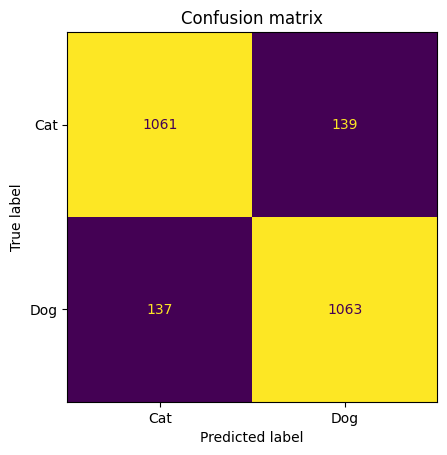

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_true, y_predict, display_labels=class_names, colorbar=False,
)
plt.title("Confusion matrix")
plt.show()